<a href="https://colab.research.google.com/github/JustinStutler/sarkar-computer-vision-lectures/blob/main/4_4_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perspective estimation: notebook functions, six experiments
Run all cells in order. Uses the commented-out **road153 / road824** image pair. The accompanying `data` folder contains the two images.

Functions are adapted directly from the supplied Module 4.4 notebook. Changes: current NumPy stacking syntax, scalar QR accumulator, configurable learning rates and iteration limits, shared affine/RANSAC initialization, final residual recomputation, and recorded convergence histories. The original Newton scaling is retained: Hessian of summed squared error, gradient of squared error divided by all matches. Thus its effective Newton multiplier is learning_rate / N.

The original stop-on-nondecrease rule is retained, but checked before taking another step. A step that increases the residual is recorded and retained so instability is visible. No extra update is taken after detecting that increase. Both methods use at most 1,000 updates.

Dependencies: numpy, matplotlib, torch, opencv-python, scikit-image. Select a Python kernel with these installed. Analysis is intentionally left for after examining the outputs.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import cv2
from skimage import io
from skimage.transform import warp

%matplotlib inline
device = torch.device('cpu')
torch.set_num_threads(1)
np.set_printoptions(precision=5, suppress=True)
SEED = 42
MAX_ITERATIONS = 1000
print('PyTorch:', torch.__version__, '| OpenCV:', cv2.__version__)


PyTorch: 2.11.0+cpu | OpenCV: 4.14.0


In [12]:
from google.colab import drive
drive.mount('/content/drive')
data_dir = '/content/drive/MyDrive/Colab Notebooks/CAP 6415 Computer Vision Online/data/'
!ls "$data_dir"

Mounted at /content/drive
 0005_Walking001.xlsx			     left01.jpg
 0008_ChaCha001.xlsx			     left02.jpg
 2011_09_26_drive_0048_sync.zip		     left03.jpg
 20211003_082148.jpg			     left04.jpg
 20211003_082201.jpg			     left05.jpg
 4.3image1.png				     left06.jpg
 4.3image2.png				     left07.jpg
 apple.jpg				     left08.jpg
'Armes 1.png'				     left09.jpg
'Armes 2.png'				     left11.jpg
 blog_danforth_monica_mural_panorama.jpg     left12.jpg
 blog_monica_mural_brown_white.jpg	     lizard.jpg
 blog_monica_mural_fish_tree_windows1.jpg    __MACOSX
'cats and dogs.jpg'			     MOT16-08-raw.webm
 convenience-store-cereal01.jpg		     mountain_peak_1.png
 declaration_of_independence_stone_630.jpg   mountain_peak_2.png
 Fig3_3a.jpg				     parking_lot_meva_1.png
 Fig3_4a.jpg				     parking_lot_meva_2.png
 Fig3_4c.jpg				     parking_lot_meva_3.png
 hawaii.png				    'Road Signs Kaggle'
 house_1.png				    'Road Signs Kaggle.zip'
 house_2.png				     semper.zip
 house_facade.png			    'Sup

## Original matching, affine fitting, and RANSAC helpers

In [13]:
def detect_and_match_keypoints (image_1, image_2) :
    # input are just two images
    # returns SIFT key points and descriptors for each image along with sorted match list (plus pairs of point matching coordinates)
    # SIFT with default parameters
    sift = cv2.SIFT_create(nOctaveLayers = 3, contrastThreshold = 0.04, edgeThreshold = 10, sigma = 1.6)

    keypoints_1, descriptors_1 = sift.detectAndCompute(image_1, None)
    keypoints_2, descriptors_2 = sift.detectAndCompute(image_2, None)

    # FEATURE MATCHING
    bf = cv2.BFMatcher(cv2.NORM_L1, crossCheck=True)

    matches = bf.match(descriptors_1, descriptors_2)
    matches = sorted(matches, key = lambda x:x.distance)
    X_1 = []
    X_2 = []
    for i in range(len(matches)) :
        X_1.append([keypoints_1[matches[i].queryIdx].pt[0], keypoints_1[matches[i].queryIdx].pt[1]])
        X_2.append([keypoints_2[matches[i].trainIdx].pt[0], keypoints_2[matches[i].trainIdx].pt[1]])
    X_1 = np.array(X_1)
    X_2 = np.array(X_2)

    return(X_1, X_2, keypoints_1, keypoints_2, matches)

In [14]:
def qr_solve (H, b) :
    # H is n by n matrix, b is a n by 1 vector
    # returns a n by 1 vector as a solution

    Q, R = np.linalg.qr(H, 'reduced')
    b_dash = Q.transpose(1,0) @ b
    Np = b_dash.shape[0]
    del_p = np.zeros((Np, 1))
    for i in range(Np-1, -1, -1): # work from the last row of R
        sum_r_p = 0.0
        for j in range(i+1, Np, 1) :
            sum_r_p += R[i, j]*del_p[j]
        if (R[i,i] != 0.0):
            del_p[i] = (b_dash[i]- sum_r_p)/R[i,i]

    return(del_p)

In [15]:
def fit_affine (X, X_dash, select_flag) :
    # input: two 2D points sets, 3 by N arrays of homogeneous representation of the points
    # select_flag: 1D array of 0 an 1 indicating which points to use in the estimation.
    # output: residual of fit and the best fitting affine transformation

    # Compute the matrix H from the point coordinate moments
    M = X @ np.diag(select_flag) @ X.transpose(1,0)
    H1 = np.column_stack((M, np.zeros((3,3))))
    H2 = np.column_stack((np.zeros((3,3)), M))
    H = np.vstack((H1, H2))

    # vector b
    b_dash = X @ np.diag(select_flag) @(X_dash - X).transpose(1,0)
    b = np.vstack((b_dash[:,0][:,None], b_dash[:,1][:,None]))

    p = qr_solve (H, b)

    p = p.squeeze()
    # the parameter vector is [a_00, a_01, t_x, a_10, a_11, t_y]
    # rearrange it back into homogeneous matrix representation
    # do not forget to add in the identity matrix. We used the (1+a_ii) parameterization
    T_affine = np.vstack((p.reshape(2, 3), [0, 0, 0])) + np.eye(3)

    X_t = T_affine @ X

    # If you want to return the total (summed) squared residual use the following
    #residual_error = np.sum(np.power((X_dash - X_t)*select_flag, 2))

    # If you want residual error per matching point in terms of pixels
    residual_error = np.sum(np.power(X_dash - X_t, 2)*select_flag)
    residual_error = np.sqrt(residual_error/np.sum(select_flag))

    return(residual_error, T_affine)


In [16]:
def ransac_N(m=4, u=0.3, p=0.99) :
    #m: minimum number of data units needed to estimate
    #u: what fraction of data are inliers
    #p: how confident we want to be in our estimate

    N = np.log(1 - p)/np.log(1 - np.power(u, m))
    return(int(N))



In [17]:
def detect_intliers (X, X_dash, Transform, acceptable_error = 2) :
    # input: two 2D points sets, 3 by N arrays of homogeneous representation of the points
    # Transform: estimated transform matrix to use to detect inliers.
    # acceptable_error - amount of average pixel error that is acceptable for inliers
    # output is an 1D array of size equal to the number of points, N, with 0 or 1,
    #        with 1 indicating the corresponding point is an inlier

    X_t = Transform @ X
    X_t = np.divide(X_t, X_t [2,:]) # normalized homogenous coordinates
    X_dash = np.divide(X_dash, X_dash [2,:]) # normalized homogenous coordinates

    error =  (X_dash - X_t)
    residual_error = np.sum(np.power(error, 2), axis=0)
    inliers  = np.where(residual_error < (acceptable_error*acceptable_error), 1, 0)

    return(inliers)


In [18]:
def ransac_fit (Points_1, Points_2, fit_function, acceptable_error = 2, min_samples=3, fraction_inlier = 0.05) :
    # input: two 2D points sets, each of size N by 2
    # fit_function: a function that computes the best fit, e.g. affine_fit
    # acceptable_error - amount of average pixel error that is acceptable
    # min_samples: number of samples per iteration
    # fraction_inlier: what fraction of the data are inliers
    # outputs: residual error, the best inlier flags, and the best fitting transformation

    # Rearrange the N by 2 sized points variable into 3 by N arrays of homogeneous representation of the points
    X = np.vstack((Points_1.transpose(1,0), np.ones((1, Points_1.shape[0]))))
    X_dash = np.vstack((Points_2.transpose(1,0), np.ones((1, Points_2.shape[0]))))

    N = X.shape[1]
    best_inliers = np.zeros((N,))
    N_ransac = ransac_N(m=min_samples, u=fraction_inlier, p=0.99)
    print('Repeating RANSAC {} times'.format(N_ransac))
    for i in range(N_ransac) :
        indices = np.random.choice(range(N), min_samples, replace=False)
        selected_pts = np.zeros((N,))
        selected_pts[indices] = 1
        residual_error, transform = fit_function (X, X_dash, selected_pts)
        inliers = detect_intliers (X, X_dash, transform, acceptable_error)
        if (np.sum(inliers) > np.sum(best_inliers)) :
            best_inliers = inliers
            transform_best = transform
            print('inlier:', np.sum(best_inliers), 'of ', N)

    selected_pts = np.zeros((N,))
    selected_pts[np.nonzero(best_inliers)] = 1
    residual_error, transform_best = fit_function (X, X_dash, selected_pts)
    return(residual_error, best_inliers, transform_best)

## Updated original PyTorch fitting functions

In [19]:
def fit_Newton_autograd(Input_points, Output_points, learning_rate=1.0,
                           max_iterations=1000, initial_fit=None):
    # Input_points, Output_points -- N by 2 sized arrays of (x, y) coordinates of points.

    # ------set up the input and output tensors -------------------------------
    # create homogeneous representation of input points (3 by N sized array)
    # and turn into torch tensors
    X1 = np.vstack((Input_points.transpose(1,0), np.ones((1, Input_points.shape[0]))))
    X = torch.tensor(X1, device = device, requires_grad=False) # homogenous coordinates

    # torch tensor for the output points
    # (2 by N sized, do not need this to be homogemnous as we will not operate on them)
    X_dash = torch.tensor(Output_points.transpose(1,0), device = device, requires_grad=False) # non-homogenous coordinates

    h_22 = torch.tensor([0.0], dtype=torch.float64, device=device)
    # fixed entry of the homography matrix, need to treat it separately
    # as we will not be computing derivative with respect to it

    # ----------------------Compute initial estimate ----------------------------
    if initial_fit is None:
        initial_fit = ransac_fit(Input_points, Output_points, fit_affine,
                                 acceptable_error=4)
    av_residual, matches_selected, T_affine = initial_fit
    if np.sum(matches_selected) < 4:
        raise ValueError('Need at least four selected inliers.')
    matches_selected = torch.tensor(np.diag(matches_selected), dtype = float, device = device, requires_grad=False)

    # initialize the 8 parameters of the perspective transform matrix. Recall, h_22 = 0, hence only 8
    h_ = (T_affine - np.eye(3)).reshape(9,)[0:8]
    # we remove an identity matrix from T_affine as per parameterization convention (p=0, represents the identity matrix)
    h_8_est = torch.tensor(h_, device = device, requires_grad=True)
    #print('h = \n', h_8_est)

    #---------------define the loss function to be optimized-----------------------------
    def fit_error (h_8): # just 8 free parameters
        # Computes the fit error of 2D homography fit between X and X_dash using h_8 parameters
        # This is what we want to minimize by varying the h_8.
        # Uses variables defined outside of the function: X, X_dash, matches_selected

        H = torch.cat((h_8, h_22), 0)
        X_t = torch.matmul(H.reshape(3,3) + torch.eye(3, device = device), X)
        # the identity matrix addition is to keep the parameterization such that
        # h_8 = 0 results in an identity transformation.

        Xt_nh = torch.div(X_t, X_t [2,:]) # normalized homogenous coordinates
        Xt_nh = Xt_nh [0:2,:]

        Xloss =  (X_dash - Xt_nh) @ matches_selected

        return(torch.pow(Xloss, 2).sum())

    history = []
    prev_residual = float('inf')
    status = 'iteration limit'
    for t in range(max_iterations + 1):
        residual = fit_error(h_8_est) / X.shape[1]
        value = residual.item()
        history.append(float(np.sqrt(value)))
        if not np.isfinite(value):
            status = 'non-finite residual'
            break
        if value >= prev_residual:
            status = 'residual increased' if value > prev_residual else 'residual unchanged'
            break
        if t == max_iterations:
            break
        prev_residual = value
        residual.backward()
        try:
            with torch.no_grad():
                Hessian = torch.autograd.functional.hessian(fit_error, h_8_est)
                del_p = learning_rate * torch.linalg.solve(Hessian, h_8_est.grad)
                h_8_est -= del_p
        except RuntimeError as error:
            status = f'update failed: {error}'
            break
        finally:
            h_8_est.grad = None

    with torch.no_grad():
        H = torch.cat((h_8_est, h_22), 0).reshape(3, 3) + torch.eye(3, device=device)
        final_residual = torch.sqrt(fit_error(h_8_est) / X.shape[1]).item()
    return final_residual, H.cpu().numpy(), matches_selected, np.array(history), status


In [20]:
def fit_grad_descent_autograd(Input_points, Output_points, learning_rate=1e-10,
                           max_iterations=1000, initial_fit=None):
    # Input_points, Output_points -- N by 2 sized arrays of (x, y) coordinates of points.

    # ------set up the input and output tensors -------------------------------
    # create homogeneous representation of input points (3 by N sized array)
    # and turn into torch tensors
    X1 = np.vstack((Input_points.transpose(1,0), np.ones((1, Input_points.shape[0]))))
    X = torch.tensor(X1, device = device, requires_grad=False) # homogenous coordinates

    # torch tensor for the output points
    # (2 by N sized, do not need this to be homogemnous as we will not operate on them)
    X_dash = torch.tensor(Output_points.transpose(1,0), device = device, requires_grad=False) # non-homogenous coordinates

    h_22 = torch.tensor([0.0], dtype=torch.float64, device=device)
    # fixed entry of the homography matrix, need to treat it separately
    # as we will not be computing derivative with respect to it

    # ----------------------Compute initial estimate ----------------------------
    if initial_fit is None:
        initial_fit = ransac_fit(Input_points, Output_points, fit_affine,
                                 acceptable_error=4)
    av_residual, matches_selected, T_affine = initial_fit
    if np.sum(matches_selected) < 4:
        raise ValueError('Need at least four selected inliers.')
    matches_selected = torch.tensor(np.diag(matches_selected), dtype = float, device = device, requires_grad=False)

    # initialize the 8 parameters of the perspective transform matrix. Recall, h_22 = 0, hence only 8
    h_ = (T_affine - np.eye(3)).reshape(9,)[0:8]
    # we remove an identity matrix from T_affine as per parameterization convention (p=0, represents the identity matrix)
    h_8_est = torch.tensor(h_, device = device, requires_grad=True)
    #print('h = \n', h_8_est)

    #---------------define the loss function to be optimized-----------------------------
    def fit_error (h_8): # just 8 free parameters
        # Computes the fit error of 2D homography fit between X and X_dash using h_8 parameters
        # This is what we want to minimize by varying the h_8.
        # Uses variables defined outside of the function: X, X_dash, matches_selected

        H = torch.cat((h_8, h_22), 0)
        X_t = torch.matmul(H.reshape(3,3) + torch.eye(3, device = device), X)
        # the identity matrix addition is to keep the parameterization such that
        # h_8 = 0 results in an identity transformation.

        Xt_nh = torch.div(X_t, X_t [2,:]) # normalized homogenous coordinates
        Xt_nh = Xt_nh [0:2,:]

        Xloss =  (X_dash - Xt_nh) @ matches_selected

        return(torch.pow(Xloss, 2).sum())

    history = []
    prev_residual = float('inf')
    status = 'iteration limit'
    for t in range(max_iterations + 1):
        residual = fit_error(h_8_est) / X.shape[1]
        value = residual.item()
        history.append(float(np.sqrt(value)))
        if not np.isfinite(value):
            status = 'non-finite residual'
            break
        if value >= prev_residual:
            status = 'residual increased' if value > prev_residual else 'residual unchanged'
            break
        if t == max_iterations:
            break
        prev_residual = value
        residual.backward()
        try:
            with torch.no_grad():
                del_p = learning_rate * h_8_est.grad
                h_8_est -= del_p
        except RuntimeError as error:
            status = f'update failed: {error}'
            break
        finally:
            h_8_est.grad = None

    with torch.no_grad():
        H = torch.cat((h_8_est, h_22), 0).reshape(3, 3) + torch.eye(3, device=device)
        final_residual = torch.sqrt(fit_error(h_8_est) / X.shape[1]).item()
    return final_residual, H.cpu().numpy(), matches_selected, np.array(history), status


## Load images and compute the shared initialization

Repeating RANSAC 36839 times
inlier: 6 of  100
inlier: 47 of  100
inlier: 75 of  100
inlier: 79 of  100


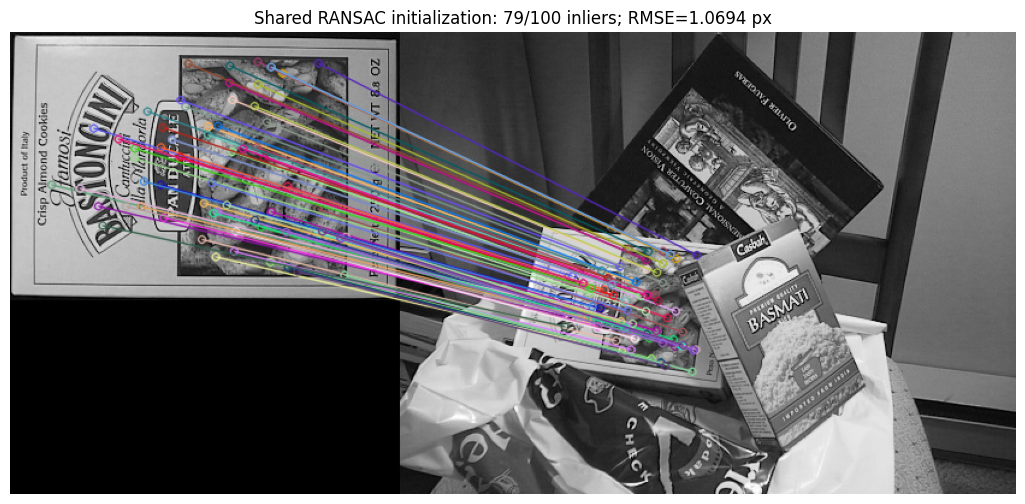

In [21]:
image_1 = io.imread(data_dir + '4.3image1.png')
image_2 = io.imread(data_dir + '4.3image2.png')
if image_1.ndim == 3:
    image_1 = cv2.cvtColor(image_1, cv2.COLOR_RGB2GRAY)
if image_2.ndim == 3:
    image_2 = cv2.cvtColor(image_2, cv2.COLOR_RGB2GRAY)
X_1, X_2, keypoints_1, keypoints_2, matches = detect_and_match_keypoints(image_1, image_2)
top_matches = min(100, len(matches))
assert top_matches >= 4, 'Need at least four matches.'
X_1, X_2 = X_1[:top_matches], X_2[:top_matches]
np.random.seed(SEED)
initial_fit = ransac_fit(X_1, X_2, fit_affine, acceptable_error=4)
initial_rmse, inlier_flags, initial_T = initial_fit
n_inliers = int(inlier_flags.sum())
assert n_inliers >= 4, 'RANSAC found fewer than four inliers.'
selected_matches = [matches[i] for i in np.flatnonzero(inlier_flags)]
match_image = cv2.drawMatches(image_1, keypoints_1, image_2, keypoints_2,
                             selected_matches, None, flags=2)
plt.figure(figsize=(14, 6))
plt.imshow(match_image, cmap='gray')
plt.title(f'Shared RANSAC initialization: {n_inliers}/{top_matches} inliers; RMSE={initial_rmse:.4f} px')
plt.axis('off')
plt.show()


## Six runs and numerical results
Notebook residual = sqrt(inlier SSE / all matches). Inlier RMSE = sqrt(inlier SSE / inlier count), in pixels. These differ because the original code divides by all matches. Iterations counts parameter updates. Elapsed time excludes shared initialization.

In [22]:
experiments = [
    ('Gradient descent', fit_grad_descent_autograd, [1e-12, 1e-10, 1e-8]),
    ('Newton', fit_Newton_autograd, [0.1, 1.0, 10.0]),
]
results = []
for method, fit_function, learning_rates in experiments:
    for lr in learning_rates:
        start = time.perf_counter()
        residual, T, selected, history, status = fit_function(
            X_1, X_2, learning_rate=lr, max_iterations=MAX_ITERATIONS,
            initial_fit=initial_fit)
        results.append(dict(method=method, lr=lr, residual=residual,
                            inlier_rmse=residual*np.sqrt(top_matches/n_inliers),
                            T=T, history=history, status=status,
                            updates=len(history)-1, seconds=time.perf_counter()-start))
        print(f'{method}, lr={lr:g}: {status}')

print(f"\n{'Method':<18} {'LR':>9} {'Residual':>12} {'Inlier RMSE':>13} {'Updates':>8} {'Seconds':>9}")
for r in results:
    print(f"{r['method']:<18} {r['lr']:>9g} {r['residual']:>12.6f} "
          f"{r['inlier_rmse']:>13.6f} {r['updates']:>8} {r['seconds']:>9.3f}")


Gradient descent, lr=1e-12: iteration limit
Gradient descent, lr=1e-10: iteration limit
Gradient descent, lr=1e-08: residual increased
Newton, lr=0.1: iteration limit
Newton, lr=1: iteration limit
Newton, lr=10: residual increased

Method                    LR     Residual   Inlier RMSE  Updates   Seconds
Gradient descent       1e-12     0.950197      1.069055     1000     0.718
Gradient descent       1e-10     0.950191      1.069049     1000     0.545
Gradient descent       1e-08     2.265046      2.548376        1     0.002
Newton                   0.1     0.509974      0.573766     1000     7.644
Newton                     1     0.431901      0.485926     1000     5.630
Newton                    10     0.431901      0.485926      149     0.840


## Convergence histories
Each curve includes the starting fit and the residual after every update, including an increasing final step if encountered.

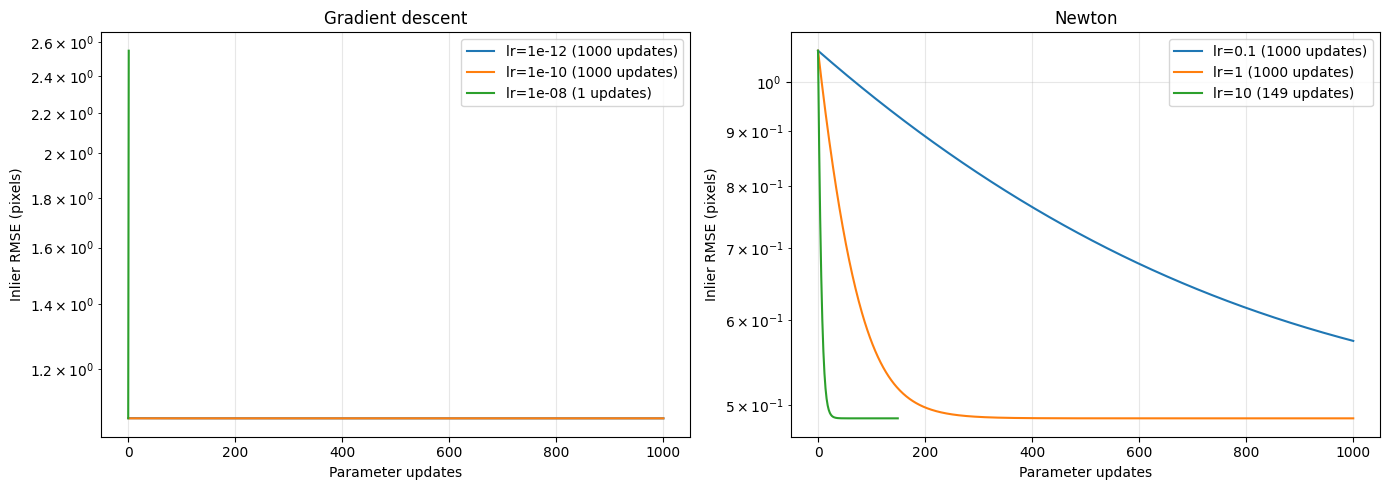

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (method, _, _) in zip(axes, experiments):
    for r in results:
        if r['method'] == method:
            ax.plot(r['history'] * np.sqrt(top_matches/n_inliers),
                    label=f"lr={r['lr']:g} ({r['updates']} updates)")
    ax.set(title=method, xlabel='Parameter updates', ylabel='Inlier RMSE (pixels)', yscale='log')
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


## Visual fits
Image 1 is warped onto image 2. Red is the warped source; cyan is the target. Inspect the corresponding road-sign edges. Unrelated backgrounds and occlusions need not align.

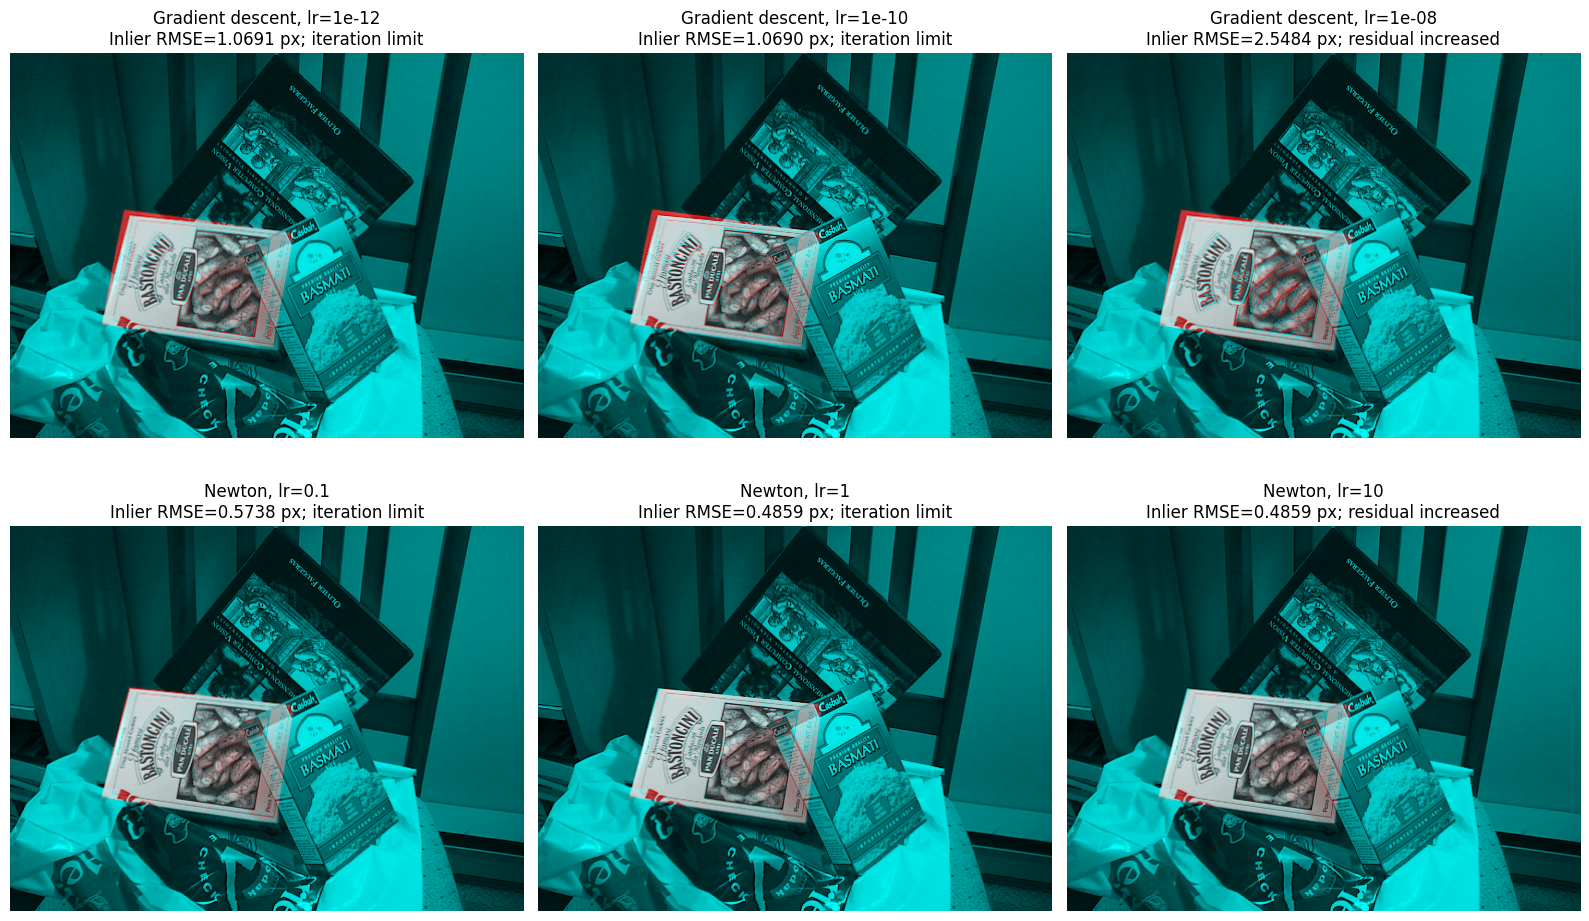

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, r in zip(axes.flat, results):
    try:
        if not np.isfinite(r['T']).all():
            raise ValueError('Non-finite transformation')
        warped = warp(image_1, inverse_map=np.linalg.inv(r['T']), output_shape=image_2.shape)
        overlay = np.stack([warped, image_2/255.0, image_2/255.0], axis=-1)
        ax.imshow(np.clip(overlay, 0, 1))
    except (ValueError, np.linalg.LinAlgError) as error:
        ax.text(0.5, 0.5, str(error), ha='center', transform=ax.transAxes)
    ax.set_title(f"{r['method']}, lr={r['lr']:g}\nInlier RMSE={r['inlier_rmse']:.4f} px; {r['status']}")
    ax.axis('off')
plt.tight_layout()
plt.show()
